# Retail clients behaviour clustering

**Course:** Mathematical Foundations of Artificial Intelligence  
**University:** Jagiellonian University  
**Authors:** Patrycja Jaworska, Mateusz Paszyński
**Year:** 2025/2026

## 0. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from math import pi
import datetime as dt

## 1. Load and cleanse Data

In [2]:
df_start = pd.read_excel('data/Online Retail.xlsx')

df = df_start.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[~df['InvoiceNo'].astype(str).str.contains('C')] #cancelled transactions

df['TotalPrice'] = df['Quantity'] * df['UnitPrice'].round(2)

now_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (now_date - x.max()).days, # Recency: days from last order
    'InvoiceNo': 'nunique',                             # Frequency: unique invoices
    'TotalPrice': 'sum'                                 # Monetary: sum
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm['Monetary'] = rfm['Monetary'].round(2)

## 2. Finding optimal number of clusters using the elbow method

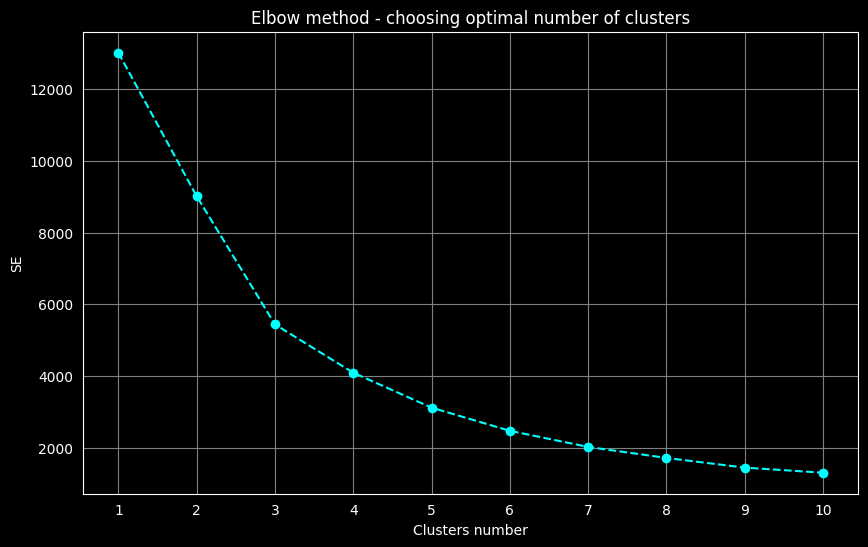

In [3]:
properties = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
properties_scaled = scaler.fit_transform(properties)

SE = []
k_range = range(1,11)

for k in k_range :
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(properties_scaled)
    SE.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, SE, marker='o', linestyle='--', color='cyan')
plt.xlabel('Clusters number')
plt.ylabel('SE')
plt.title('Elbow method - choosing optimal number of clusters')
plt.grid(True,color='grey')
plt.xticks(k_range)
plt.show()


## 3. K-Means Clustering
From image above we choose 3 as our number of clusters

In [4]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters = kmeans.fit_transform(properties_scaled)

rfm['Cluster'] = kmeans.labels_
print(rfm.head())


   CustomerID  Recency  Frequency  Monetary  Cluster
0       12346      326          1  77183.60        0
1       12347        2          7   4310.00        1
2       12348       75          4   1797.24        1
3       12349       19          1   1757.55        1
4       12350      310          1    334.40        0


## 4. Calculating means for each property in clusters

In [5]:
profil_klastrow = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(profil_klastrow)

        Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0        247.11      1.58    631.42  1082
1         41.45      4.67   1855.94  3230
2          6.04     66.42  85904.35    26


### 5. Customer Profile Analysis and Business Interpretation

Based on the average RFM values, we can characterize the identified clusters as three distinct buyer personas. This segmentation allows for marketing cost optimization and tailored communication strategies.

#### Cluster 2: VIP Customers 26 customers
* **Behavioral Characteristics:** Extremely high cart value (average ~85,00$) and very high frequency (average 66 transactions). These are highly active customers who made a purchase very recently (Recency = 6 days).
* **Interpretation and Conclusions:** Despite making up a fraction of a percent of the entire database, they generate massive revenue. Most likely, these are wholesalers or B2B partners. Losing even a single customer from this group would have a significant financial impact, which is why they require an individualized approach (e.g., a dedicated account manager, exclusive VIP offers).

#### Cluster 1: Loyal Customers 3,230 customers
* **Behavioral Characteristics:** The largest group, forming the foundation of the business. They purchase quite regularly (about 4-5 transactions) and spend decent amounts (around 1,850$). Their last purchase was, on average, a little over a month ago (Recency = 41 days).
* **Interpretation and Conclusions:** This is the "healthy" tissue of the store – retail customers who trust the brand. The main analytical goal for this group should be increasing their average order value (upselling) and maintaining their loyalty through standard email marketing and reward programs.

#### Cluster 0: Lost / One-off Customers 1,082 customers
* **Behavioral Characteristics:** Very infrequent buyers (average 1.5 transactions) with the lowest cart value (about 630$). Crucially, they haven't visited the store in almost 8 months (Recency = 247 days).
* **Interpretation and Conclusions:** The "hibernating" part of the database. These are customers who probably made a one-off purchase and moved on to the competition. The store shouldn't burn its standard advertising budget on them. Instead, it's worth implementing a one-time, aggressive win-back campaign (e.g., "We miss you, here is a 20% discount" emails).

## 6. Cluster stability evaluation
Cluster stability was evaluated by running the K-Means algorithm multiple times for the same number of clusters, but with varying random_state initializations. The clustering results were then compared using the Adjusted Rand Index (ARI). A high ARI score indicates that customers are assigned to similar groups regardless of the algorithm's initial centroid placement. Consequently, this confirms that the obtained clustering partition is highly stable.

In [6]:
from sklearn.metrics import adjusted_rand_score
label_list = []
for seed in range (100):
    kmeans_temp=KMeans(n_clusters=3, random_state=seed, n_init=10)
    label_temp=kmeans_temp.fit_predict(properties_scaled)
    label_list.append(label_temp)

ari_scores=[]
for i in range(len(label_list)):
    for j in range(i+1,len(label_list)):
        score=adjusted_rand_score(label_list[i],label_list[j])
        ari_scores.append(score)

print("Average ARI score:", round(np.mean(ari_scores), 4))
print("Minimum ARI score:", round(np.min(ari_scores), 4))
print("Maximum ARI score:", round(np.max(ari_scores), 4))


Average ARI score: 0.9977
Minimum ARI score: 0.9932
Maximum ARI score: 1.0


## 7. PCA visualization
The PCA  method was utilized to reduce the dimensionality from three RFM features down to two dimensions. This enabled the representation of customer segments on a 2D scatter plot. Each point denotes a single customer, and the point's color corresponds to the cluster assigned by the K-Means algorithm. This visualization allows us to assess whether the formed customer groups are visibly separated from one another in the lower-dimensional space

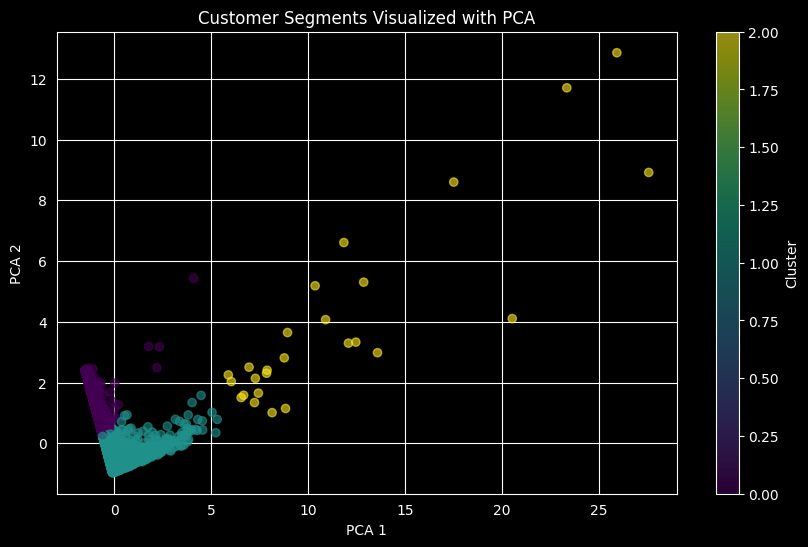

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(properties_scaled)

rfm['PCA1'] = pca_result[:, 0]
rfm['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['PCA1'],
    rfm['PCA2'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Segments Visualized with PCA')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

## 8. t-SNE visualisation
The t-SNE method was applied as an additional technique for visualizing data in two dimensions. Unlike PCA, t-SNE is a non-linear dimensionality reduction method that better captures local similarities between customers. In the scatter plot, each point represents a single customer, and the color indicates their assigned cluster. This visualization helps to verify whether customers belonging to the same segment are grouped closely together.

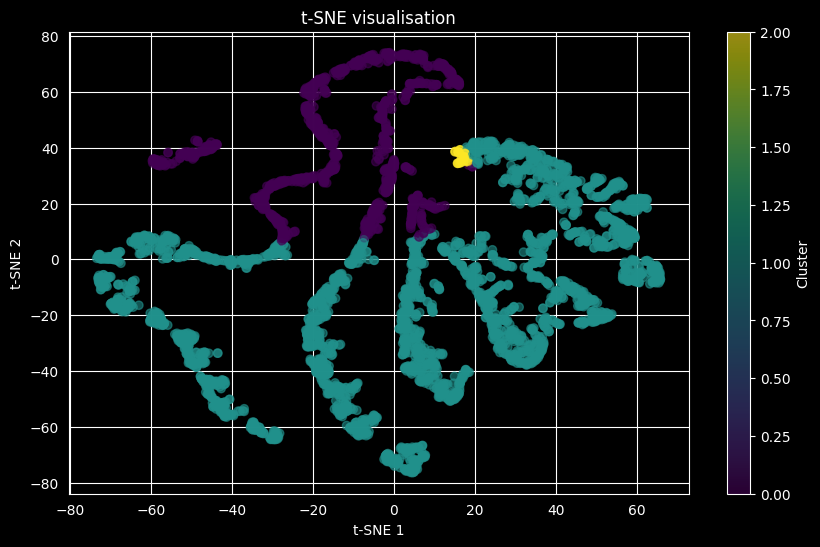

In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate='auto',
    init='pca'
)

tsne_result = tsne.fit_transform(properties_scaled)

rfm['TSNE1'] = tsne_result[:, 0]
rfm['TSNE2'] = tsne_result[:, 1]

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['TSNE1'],
    rfm['TSNE2'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE visualisation')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

## 9. Radar chart of customers' behaviour
The radar chart presents a comparison of the average RFM feature values for each cluster. Prior to plotting, the data was standardized, as Recency, Frequency, and Monetary metrics operate on entirely different scales. This standardization makes it easier to accurately compare the profiles of individual customer groups and identify which features are most characteristic for each segment

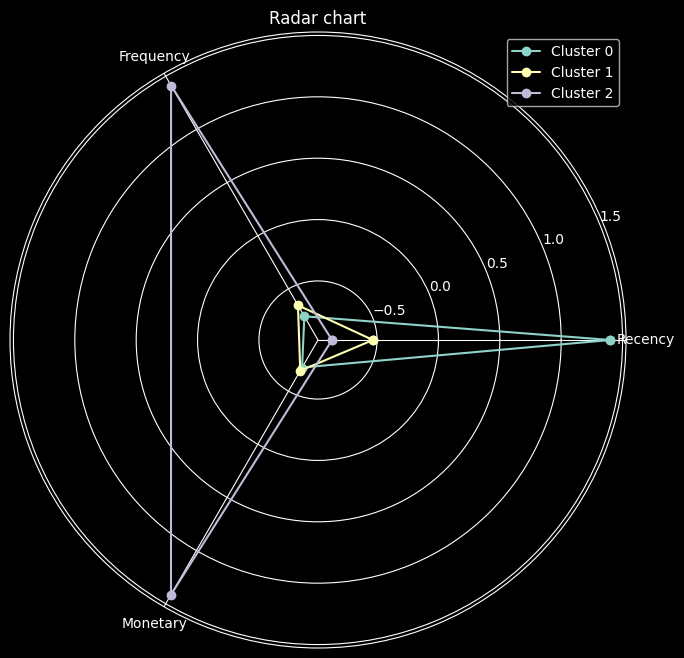

In [11]:
cluster_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

scaler_profile = StandardScaler()

cluster_profiles_scaled = pd.DataFrame(
    scaler_profile.fit_transform(cluster_profiles),
    columns=cluster_profiles.columns,
    index=cluster_profiles.index
)

categories = list(cluster_profiles_scaled.columns)
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))

for cluster in cluster_profiles_scaled.index:
    values = cluster_profiles_scaled.loc[cluster].tolist()
    values += values[:1]

    plt.polar(
        angles,
        values,
        marker='o',
        label=f'Cluster {cluster}'
    )

plt.xticks(angles[:-1], categories)
plt.title('Radar chart')
plt.legend()
plt.show()

# 10. EXPERIMENT - INCORPORATING CANCELLATION RATE
The experiment involving the addition of a fourth dimension (Cancellation_Rate) yielded highly valuable methodological insights. Unlike the classic 3D RFM model, the 4-dimensional approach led to a drastic blurring of boundaries between the clusters. As illustrated by the PCA and t-SNE projections below, customer groups ceased to form clearly separated, cohesive segments.

Analytical and Business Interpretation:
Mathematically, this occurs because the new variable introduced variance that is poorly correlated with the main purchasing patterns (Recency, Frequency, Monetary). Within the Euclidean distance metric utilized by the K-Means algorithm, differences in the cancellation rate acted as noise, effectively disrupting the natural density and spherical shape of the clusters.

From a business perspective, the experiment proves that the tendency to cancel orders is largely independent of a customer's overall value and purchase frequency—it is a behavior that occurs across all segments. The conclusion is clear: the phenomenon of order cancellations does not define global customer profiles and should not be integrated into the main segmentation algorithm. Instead, the return rate should be modeled separately or treated strictly as a secondary diagnostic metric analyzed within the already established, stable RFM clusters.

In [13]:
total_orders = df_start.groupby('CustomerID')['InvoiceNo'].nunique()
canceled_orders = df_start[df_start['InvoiceNo'].astype(str).str.contains('C')].groupby('CustomerID')['InvoiceNo'].nunique()

cancellation_df = pd.DataFrame({'Total_Orders': total_orders, 'Canceled_Orders': canceled_orders}).fillna(0)
cancellation_df['Cancellation_Rate'] = cancellation_df['Canceled_Orders'] / cancellation_df['Total_Orders']

#Merging with existing RFM table to create RFMC
rfmc = rfm.copy()
rfmc = rfmc.merge(cancellation_df[['Cancellation_Rate']], on='CustomerID', how='left').fillna(0)


scaler = StandardScaler()
rfmc_scaled = scaler.fit_transform(rfmc)

# 3. ELBOW METHOD FOR RFMC
wcss = []
for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_temp.fit(rfmc_scaled)
    wcss.append(kmeans_temp.inertia_)


kmeans_exp = KMeans(n_clusters=4, random_state=42, n_init=10)
rfmc['Cluster'] = kmeans_exp.fit_predict(rfmc_scaled)

# 4. DIMENSIONALITY REDUCTION (PCA & t-SNE)
pca_exp = PCA(n_components=2)
rfmc['PCA1'] = pca_exp.fit_transform(rfmc_scaled)[:, 0]
rfmc['PCA2'] = pca_exp.fit_transform(rfmc_scaled)[:, 1]

tsne_exp = TSNE(n_components=2, random_state=42, init='pca')
tsne_res = tsne_exp.fit_transform(rfmc_scaled)
rfmc['tSNE1'] = tsne_res[:, 0]
rfmc['tSNE2'] = tsne_res[:, 1]

cluster_means = rfmc[['Recency', 'Frequency', 'Monetary', 'Cancellation_Rate', 'Cluster']].groupby('Cluster').mean()
print("\nRaw Cluster Means (for interpretation):")
display(cluster_means.round(3))



Raw Cluster Means (for interpretation):


,Recency,Frequency,Monetary,Cancellation_Rate
Cluster,,,,
0,27.853,8.678,3759.021,0.165
1,247.106,1.582,631.424,0.095
2,50.776,1.971,638.923,0.071
3,5.682,72.091,92740.029,0.161


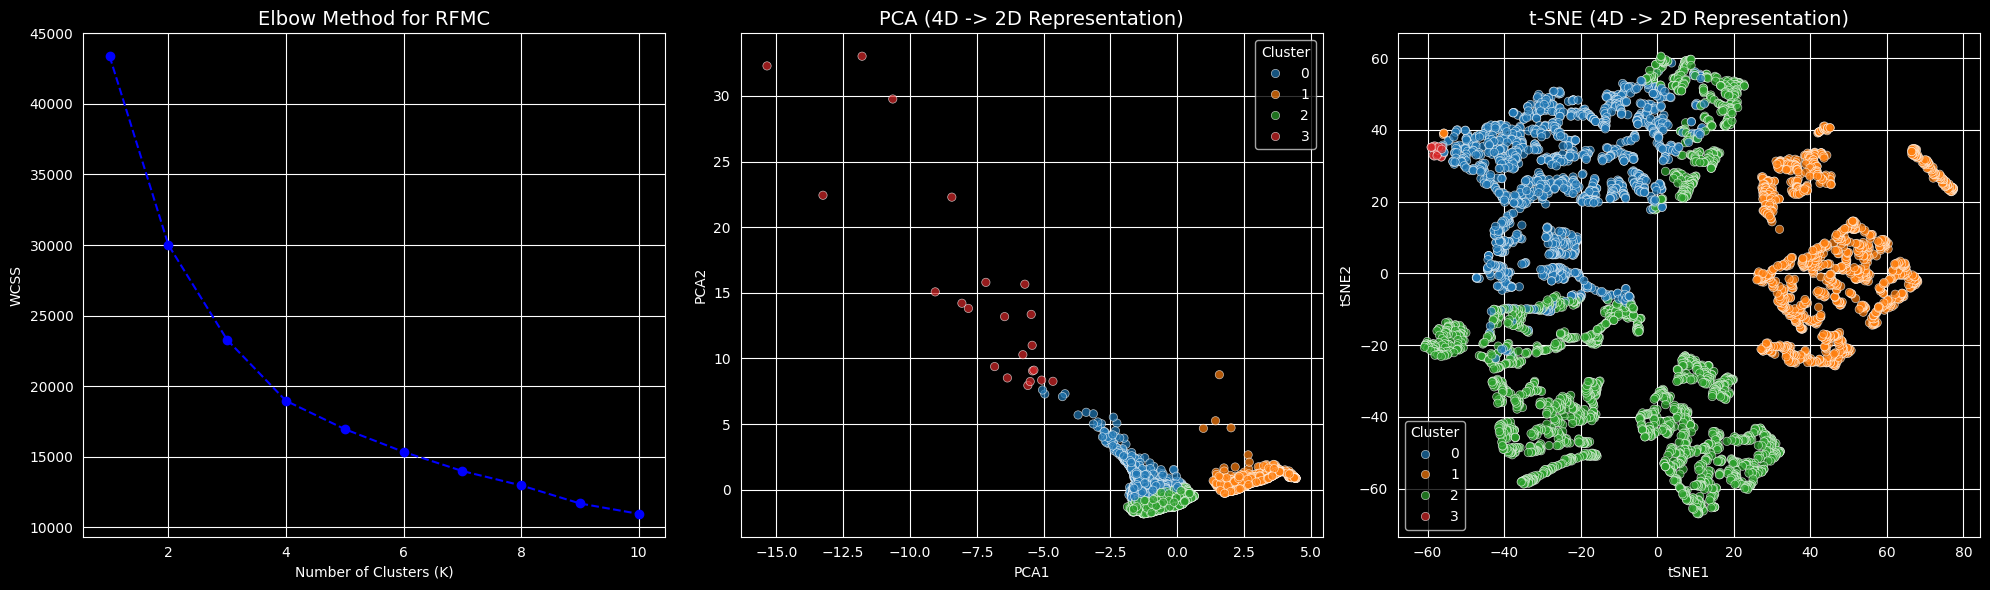

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 1 wiersz, 3 kolumny

# Wykres 1: Elbow Method
axes[0].plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
axes[0].set_title('Elbow Method for RFMC', fontsize=14)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].grid(True)

# Wykres 2: PCA
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=rfmc, palette='tab10', alpha=0.7, ax=axes[1])
axes[1].set_title('PCA (4D -> 2D Representation)', fontsize=14)

# Wykres 3: t-SNE
sns.scatterplot(x='tSNE1', y='tSNE2', hue='Cluster', data=rfmc, palette='tab10', alpha=0.7, ax=axes[2])
axes[2].set_title('t-SNE (4D -> 2D Representation)', fontsize=14)

plt.tight_layout()
plt.show()

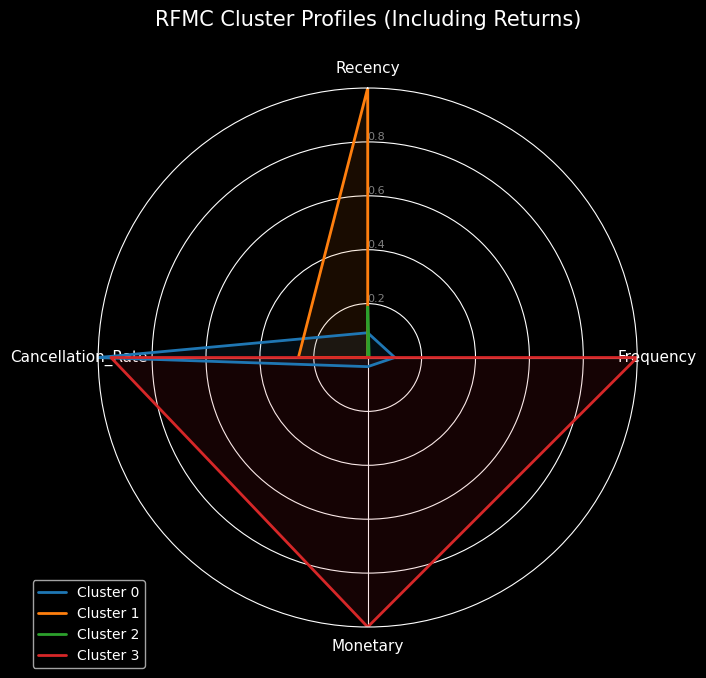

In [15]:
minmax = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(minmax.fit_transform(cluster_means), columns=cluster_means.columns)

categories = list(cluster_means.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, size=11)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2","0.4","0.6","0.8"], color="grey", size=8)
plt.ylim(0, 1)

colors = sns.color_palette('tab10', 4).as_hex()
for i in range(4):
    values = cluster_means_scaled.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, linestyle='solid', label=f'Cluster {i}')
    ax.fill(angles, values, color=colors[i], alpha=0.1)

plt.title('RFMC Cluster Profiles (Including Returns)', size=15, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()